# TI / SI / LI Weight Optimization — Constrained Grid Search

**Objective:** Find the `(w_TI, w_SI, w_LI)` weighting combination (5 % steps, sum = 100 %) that maximises  
revenue-per-hour **lift** in the top-scoring decile of corridor × time-window buckets.

> **Lift** = mean_rph(top-10 % windows by composite score) / mean_rph(all windows)

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                       'matplotlib', 'seaborn', 'mpltern', 'openpyxl'])

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    import mpltern
    HAS_MPLTERN = True
    print('mpltern available — ternary plot enabled')
except ImportError:
    HAS_MPLTERN = False
    print('mpltern not available — using barycentric fallback')

DATA_PATH   = 'Seasonal_Intensity_4.xlsx'   # ← update filename here
MIN_FLIGHTS = 5      # min flights per corridor+TOD window
GRID_STEP   = 0.05   # 5 % increments
TOP_DECILE  = 0.10   # top 10 %

print('Setup complete.')

mpltern available — ternary plot enabled
Setup complete.


## Step 1 — Load Data & Compute Revenue-per-Hour

In [2]:
df = pd.read_excel(DATA_PATH, index_col=0)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

# Hours — actual first, fall back to estimated
df['hours'] = df['flightActualBilledHours']
mask_bad = df['hours'].isna() | (df['hours'] <= 0)
df.loc[mask_bad, 'hours'] = df.loc[mask_bad, 'flightEstimatedBilledHours']

# Drop invalid cost or hours
before = len(df)
df = df[(df['hours'] > 0) & df['flightcost'].notna() & (df['flightcost'] > 0)].copy()
print(f'After cost/hours filter: {len(df):,} rows retained ({before - len(df):,} dropped)')

df['revenue_per_hour'] = df['flightcost'] / df['hours']

rph = df['revenue_per_hour']
print(f'Revenue-per-hour  min=${rph.min():,.0f}  median=${rph.median():,.0f}  '
      f'mean=${rph.mean():,.0f}  max=${rph.max():,.0f}')

Loaded: 115,071 rows, 66 columns
After cost/hours filter: 111,926 rows retained (3,145 dropped)
Revenue-per-hour  min=$1  median=$8,180  mean=$9,535  max=$72,044


## Step 2 — Parse Categorical Intensity Levels to Numeric Midpoints

| String | Midpoint |
|---|---|
| `"0 - 1"` | 0.5 |
| `"3 - 4"` | 3.5 |
| `"10+"` | 10.0 |

In [3]:
def level_to_midpoint(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == '10+':
        return 10.0
    if ' - ' in s:
        lo, hi = s.split(' - ')
        return (float(lo) + float(hi)) / 2.0
    try:
        return float(s)
    except ValueError:
        return np.nan

df['TI_numeric'] = df['TI Level'].apply(level_to_midpoint)
df['LI_numeric'] = df['LI Level'].apply(level_to_midpoint)
df['SI_numeric'] = pd.to_numeric(df['SI_Toggle'], errors='coerce')

for col in ['TI_numeric', 'LI_numeric', 'SI_numeric']:
    n_valid   = df[col].notna().sum()
    n_missing = df[col].isna().sum()
    print(f'{col}: {n_valid:,} valid  {n_missing:,} missing')

print()
print('TI range:', df['TI_numeric'].min(), '→', df['TI_numeric'].max())
print('SI range:', df['SI_numeric'].min(), '→', df['SI_numeric'].max())
print('LI range:', df['LI_numeric'].min(), '→', df['LI_numeric'].max())

TI_numeric: 105,871 valid  6,055 missing
LI_numeric: 105,871 valid  6,055 missing
SI_numeric: 89,183 valid  22,743 missing

TI range: 0.5 → 10.0
SI range: 0.0 → 5.0
LI range: 0.5 → 10.0


## Step 3 — Min-Max Normalize Each Signal to [0, 1]

Normalisation makes the three signals comparable so weights are meaningful.

In [4]:
for norm_col, raw_col in [('TI_norm', 'TI_numeric'),
                           ('SI_norm', 'SI_numeric'),
                           ('LI_norm', 'LI_numeric')]:
    mn = df[raw_col].min()
    mx = df[raw_col].max()
    df[norm_col] = (df[raw_col] - mn) / (mx - mn)
    print(f'{norm_col}: [{df[norm_col].min():.3f}, {df[norm_col].max():.3f}]  '
          f'(from raw [{mn}, {mx}])')

TI_norm: [0.000, 1.000]  (from raw [0.5, 10.0])
SI_norm: [0.000, 1.000]  (from raw [0.0, 5.0])
LI_norm: [0.000, 1.000]  (from raw [0.5, 10.0])


## Step 4 — Drop Incomplete Rows & Aggregate to Corridor + TOD Windows

Rows missing any of TI / SI / LI cannot contribute to a composite score and are dropped.  
We then aggregate to corridor × TOD level and require at least **5 flights** per window.

In [5]:
df_clean = df.dropna(subset=['TI_norm', 'SI_norm', 'LI_norm']).copy()
print(f'After dropping missing-intensity rows: {len(df_clean):,} rows '
      f'({len(df) - len(df_clean):,} dropped)')

agg = (
    df_clean
    .groupby(['corridor', 'TOD'], as_index=False)
    .agg(
        mean_rph     = ('revenue_per_hour', 'mean'),
        median_rph   = ('revenue_per_hour', 'median'),
        flight_count = ('revenue_per_hour', 'count'),
        TI_norm_mean = ('TI_norm', 'mean'),
        SI_norm_mean = ('SI_norm', 'mean'),
        LI_norm_mean = ('LI_norm', 'mean'),
        TI_raw_mean  = ('TI_numeric', 'mean'),
        SI_raw_mean  = ('SI_numeric', 'mean'),
        LI_raw_mean  = ('LI_numeric', 'mean'),
    )
)

agg = agg[agg['flight_count'] >= MIN_FLIGHTS].reset_index(drop=True)
print(f'Aggregated windows (≥{MIN_FLIGHTS} flights): {len(agg):,}')
print(agg['flight_count'].describe().round(1).to_string())

After dropping missing-intensity rows: 89,183 rows (22,743 dropped)
Aggregated windows (≥5 flights): 1,800
count    1800.0
mean       49.1
std        61.7
min         5.0
25%        13.0
50%        27.0
75%        56.0
max       459.0


## Step 5 — Build Constrained Weight Grid

All `(w_TI, w_SI, w_LI)` triples at **5 % steps** where `w_TI + w_SI + w_LI = 1.0`.

In [6]:
step = int(GRID_STEP * 100)
weights = []
for ti in range(0, 101, step):
    for si in range(0, 101 - ti, step):
        li = 100 - ti - si
        if li >= 0:
            weights.append((ti / 100.0, si / 100.0, li / 100.0))

W = np.array(weights)   # (231, 3)
assert np.allclose(W.sum(axis=1), 1.0), 'Weights do not sum to 1.0!'
print(f'Valid weight combinations: {len(W)}')

# Feature matrix and target vector
F   = agg[['TI_norm_mean', 'SI_norm_mean', 'LI_norm_mean']].values  # (n_windows, 3)
rph = agg['mean_rph'].values

global_mean_rph = rph.mean()
top_k = max(1, int(len(agg) * TOP_DECILE))
print(f'Global mean RPH: ${global_mean_rph:,.0f}')
print(f'Top-decile threshold: top {top_k} of {len(agg)} windows')

Valid weight combinations: 231
Global mean RPH: $9,547
Top-decile threshold: top 180 of 1800 windows


## Step 6 — Grid Search (vectorised, ~15 ms)

In [7]:
import time
t0 = time.time()

# Score matrix: (n_combos × n_windows)
scores = W @ F.T   # (231, n_windows)

lifts            = np.zeros(len(W))
top_decile_mrph  = np.zeros(len(W))

for i in range(len(W)):
    top_idx = np.argsort(scores[i])[-top_k:]
    top_decile_mrph[i] = rph[top_idx].mean()
    lifts[i]           = top_decile_mrph[i] / global_mean_rph

elapsed = time.time() - t0
print(f'Grid search complete in {elapsed*1000:.1f} ms')

results = pd.DataFrame(W, columns=['w_TI', 'w_SI', 'w_LI'])
results['lift']            = lifts
results['top_decile_mrph'] = top_decile_mrph
results = results.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Lift range: {lifts.min():.4f} → {lifts.max():.4f}')

# Locate current baseline (0.60 / 0.30 / 0.10)
baseline_mask = (np.isclose(results.w_TI, 0.6) &
                 np.isclose(results.w_SI, 0.3) &
                 np.isclose(results.w_LI, 0.1))
if baseline_mask.any():
    baseline_lift = results.loc[baseline_mask, 'lift'].values[0]
    baseline_rank = results.index[baseline_mask][0] + 1
    print(f'Baseline (0.60/0.30/0.10): lift={baseline_lift:.4f}  rank #{baseline_rank}')
else:
    baseline_lift = None
    print('Baseline (0.60/0.30/0.10) not found in grid — check GRID_STEP')

Grid search complete in 33.7 ms
Lift range: 1.0162 → 1.1265
Baseline (0.60/0.30/0.10): lift=1.0974  rank #52


## Step 7 — Top 10 Weight Combinations

In [8]:
winner = results.iloc[0]

top10 = results.head(10).copy()
top10.insert(0, 'Rank', range(1, 11))
top10['w_TI %'] = (top10.w_TI * 100).astype(int).astype(str) + ' %'
top10['w_SI %'] = (top10.w_SI * 100).astype(int).astype(str) + ' %'
top10['w_LI %'] = (top10.w_LI * 100).astype(int).astype(str) + ' %'
top10['Lift']   = top10.lift.apply(lambda x: f'{x:.4f}')
top10['Top-Decile Mean RPH'] = top10.top_decile_mrph.apply(lambda x: f'${x:,.0f}')

display(top10[['Rank','w_TI %','w_SI %','w_LI %','Lift','Top-Decile Mean RPH']])

print()
print('=' * 60)
print(f'WINNER: w_TI={winner.w_TI:.2f}  w_SI={winner.w_SI:.2f}  w_LI={winner.w_LI:.2f}')
print(f'Lift  : {winner.lift:.4f}  ({(winner.lift - 1)*100:.1f} % above global mean RPH)')
print(f'Top-decile mean RPH : ${winner.top_decile_mrph:,.0f}')
print(f'Global mean RPH     : ${global_mean_rph:,.0f}')
if baseline_lift is not None:
    improvement = (winner.lift - baseline_lift) / baseline_lift * 100
    print(f'Improvement over baseline: +{improvement:.2f} %')
print('=' * 60)

,Rank,w_TI %,w_SI %,w_LI %,Lift,Top-Decile Mean RPH
0,1,35 %,50 %,15 %,1.1265,"$10,755"
1,2,35 %,45 %,20 %,1.1217,"$10,708"
2,3,30 %,55 %,15 %,1.1207,"$10,699"
3,4,30 %,50 %,20 %,1.1202,"$10,694"
4,5,40 %,45 %,15 %,1.1200,"$10,693"
5,6,75 %,5 %,20 %,1.1200,"$10,693"
6,7,70 %,5 %,25 %,1.1194,"$10,687"
7,8,40 %,50 %,10 %,1.1194,"$10,687"
8,9,40 %,55 %,5 %,1.1186,"$10,679"
9,10,35 %,55 %,10 %,1.1185,"$10,679"



WINNER: w_TI=0.35  w_SI=0.50  w_LI=0.15
Lift  : 1.1265  (12.6 % above global mean RPH)
Top-decile mean RPH : $10,755
Global mean RPH     : $9,547
Improvement over baseline: +2.65 %


## Step 8 — Visualisations

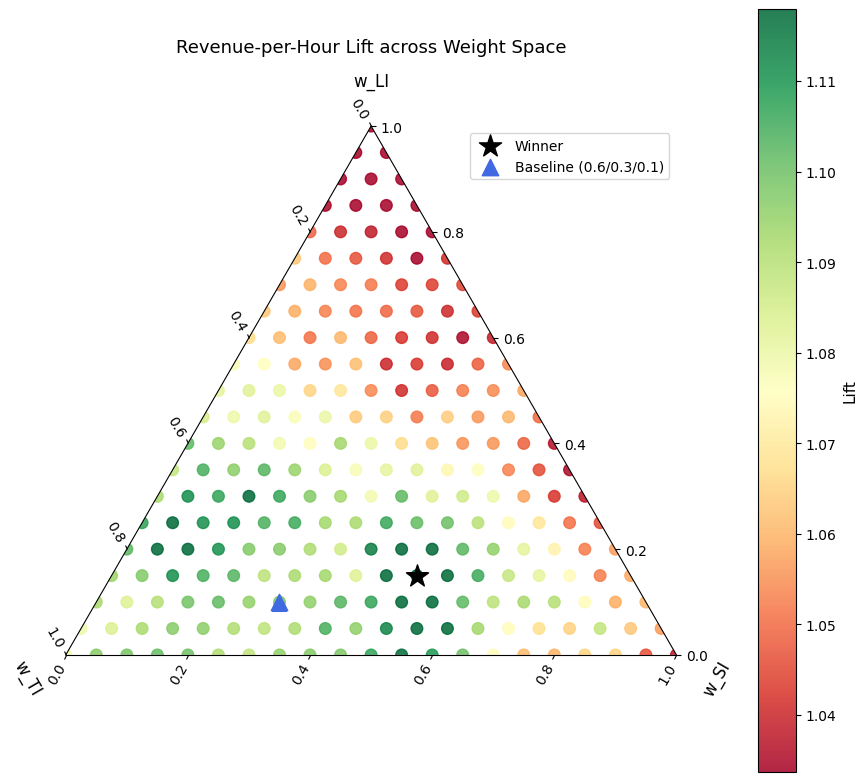

Saved: weight_optimization_ternary.png


In [9]:
# ── Plot A: Ternary / barycentric scatter ─────────────────────────────────────
if HAS_MPLTERN:
    fig = plt.figure(figsize=(9, 8))
    ax_t = fig.add_subplot(projection='ternary')
    # mpltern axes: top=w_LI, left=w_TI, right=w_SI
    pc = ax_t.scatter(
        results.w_LI, results.w_TI, results.w_SI,
        c=results.lift, cmap='RdYlGn', s=70, alpha=0.85,
        vmin=results.lift.quantile(0.05),
        vmax=results.lift.quantile(0.95)
    )
    ax_t.set_tlabel('w_LI', fontsize=12)
    ax_t.set_llabel('w_TI', fontsize=12)
    ax_t.set_rlabel('w_SI', fontsize=12)
    ax_t.set_title('Revenue-per-Hour Lift across Weight Space', pad=15, fontsize=13)
    cb = fig.colorbar(pc, ax=ax_t, pad=0.1)
    cb.set_label('Lift', fontsize=11)
    ax_t.scatter([winner.w_LI], [winner.w_TI], [winner.w_SI],
                 marker='*', color='black', s=280, zorder=5, label='Winner')
    if baseline_lift is not None:
        ax_t.scatter([0.1], [0.6], [0.3], marker='^', color='royalblue',
                     s=140, zorder=5, label='Baseline (0.6/0.3/0.1)')
    ax_t.legend(loc='upper right', fontsize=10)
else:
    # Barycentric 2-D projection: TI apex=bottom-left, SI apex=bottom-right, LI apex=top
    fig, ax = plt.subplots(figsize=(9, 8))
    x_c = results.w_SI + results.w_LI * 0.5
    y_c = results.w_LI * (np.sqrt(3) / 2)
    sc = ax.scatter(x_c, y_c, c=results.lift, cmap='RdYlGn', s=70, alpha=0.85,
                    vmin=results.lift.quantile(0.05),
                    vmax=results.lift.quantile(0.95))
    plt.colorbar(sc, ax=ax, label='Lift')
    # Triangle outline
    tri_x = [0, 1, 0.5, 0]; tri_y = [0, 0, np.sqrt(3)/2, 0]
    ax.plot(tri_x, tri_y, 'k-', lw=1.5)
    ax.text(-0.06, -0.04, 'w_TI=1', ha='center', fontsize=10)
    ax.text( 1.06, -0.04, 'w_SI=1', ha='center', fontsize=10)
    ax.text( 0.50, np.sqrt(3)/2 + 0.04, 'w_LI=1', ha='center', fontsize=10)
    wx = winner.w_SI + winner.w_LI * 0.5
    wy = winner.w_LI * (np.sqrt(3)/2)
    ax.scatter([wx], [wy], marker='*', color='black', s=280, zorder=5, label='Winner')
    if baseline_lift is not None:
        bx = 0.3 + 0.1 * 0.5; by = 0.1 * (np.sqrt(3)/2)
        ax.scatter([bx], [by], marker='^', color='royalblue', s=140,
                   zorder=5, label='Baseline (0.6/0.3/0.1)')
    ax.legend(fontsize=10); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('Revenue-per-Hour Lift across Weight Space\n(barycentric projection)',
                 fontsize=13)

plt.tight_layout()
plt.savefig(r'e:\agntworks_playground\weight_optimization_ternary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weight_optimization_ternary.png')

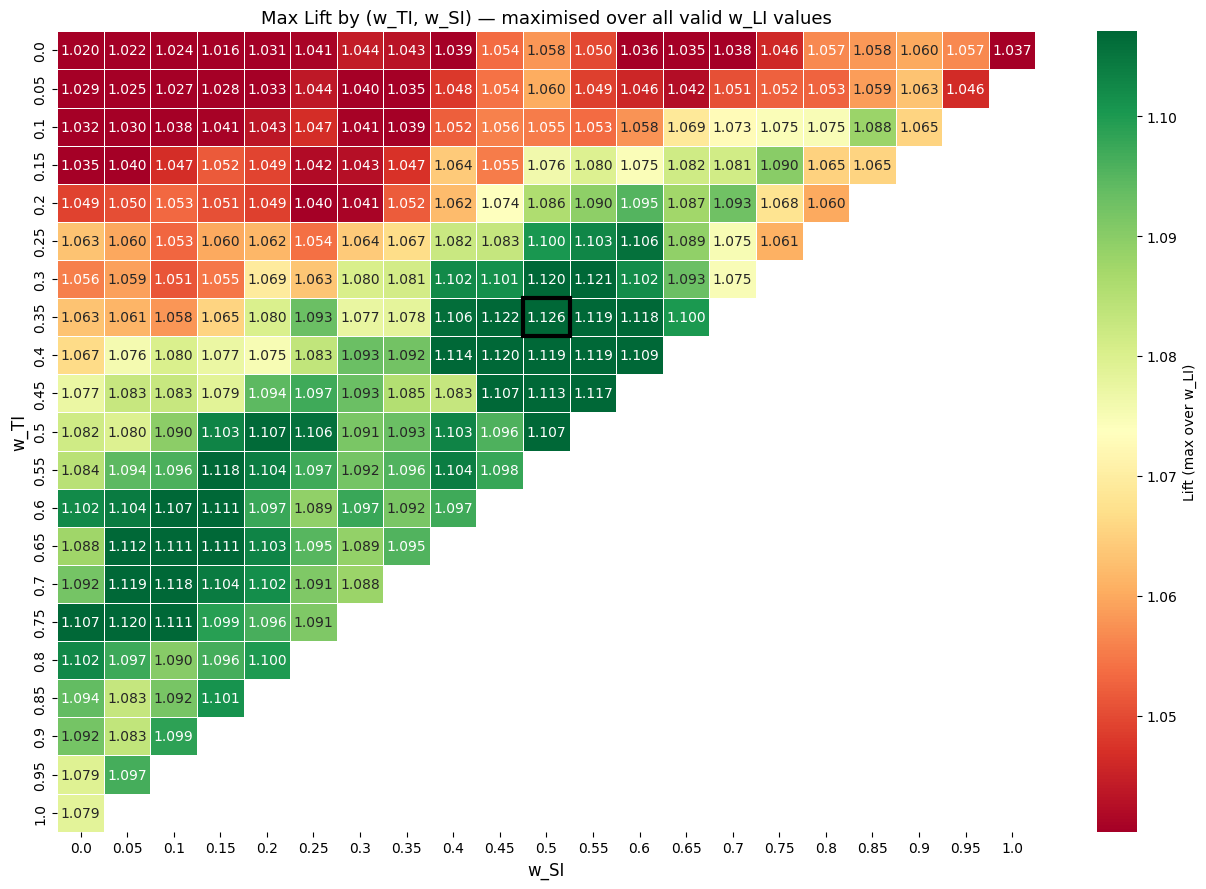

Saved: lift_heatmap_wTI_wSI.png


In [10]:
# ── Plot B: Seaborn heatmap — w_TI vs w_SI (max lift over w_LI) ──────────────
pivot = results.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')

fig, ax = plt.subplots(figsize=(13, 9))
vlo = results.lift.quantile(0.10)
vhi = results.lift.quantile(0.90)
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Lift (max over w_LI)'},
    vmin=vlo, vmax=vhi
)

# Highlight winning cell
w_ti_vals = list(pivot.index)
w_si_vals = list(pivot.columns)
try:
    ri = min(range(len(w_ti_vals)), key=lambda i: abs(w_ti_vals[i] - winner.w_TI))
    ci = min(range(len(w_si_vals)), key=lambda i: abs(w_si_vals[i] - winner.w_SI))
    ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='black', lw=3))
except Exception:
    pass

ax.set_title('Max Lift by (w_TI, w_SI) — maximised over all valid w_LI values', fontsize=13)
ax.set_xlabel('w_SI', fontsize=12)
ax.set_ylabel('w_TI', fontsize=12)

plt.tight_layout()
plt.savefig(r'e:\agntworks_playground\lift_heatmap_wTI_wSI.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_heatmap_wTI_wSI.png')

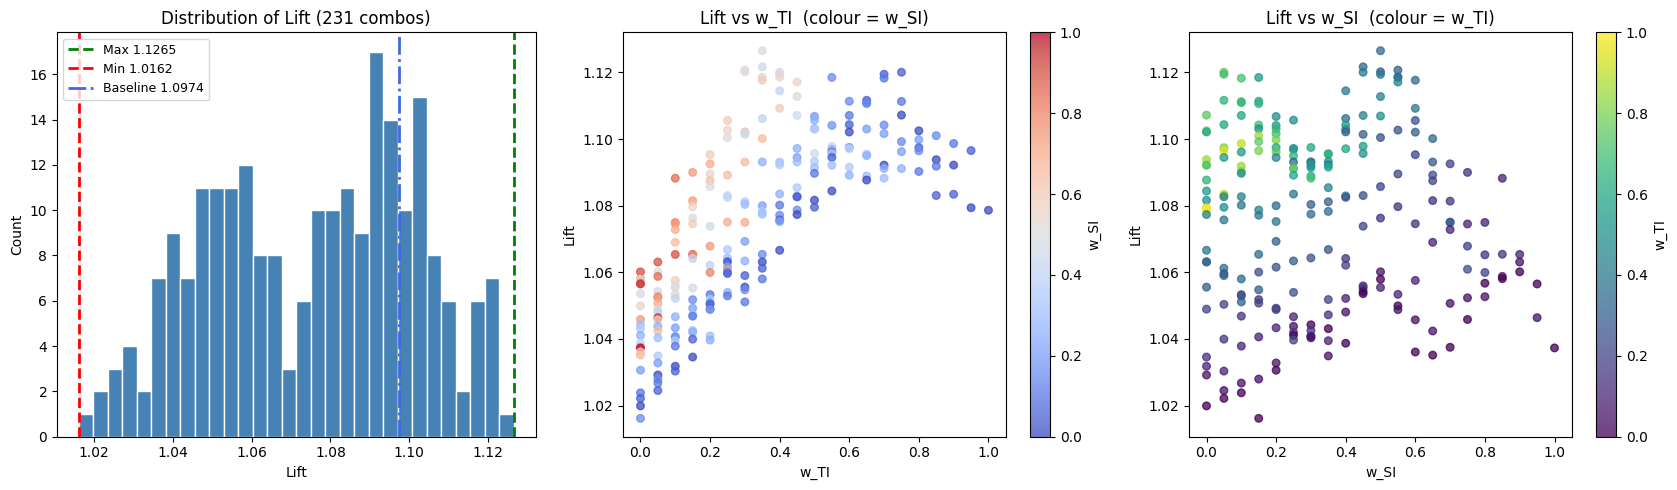

Saved: lift_scatter_analysis.png


In [11]:
# ── Plot C: Scatter diagnostics — lift vs each weight dimension ───────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Lift histogram
axes[0].hist(results.lift, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(results.lift.max(), color='green',  ls='--', lw=2, label=f'Max {results.lift.max():.4f}')
axes[0].axvline(results.lift.min(), color='red',    ls='--', lw=2, label=f'Min {results.lift.min():.4f}')
if baseline_lift is not None:
    axes[0].axvline(baseline_lift, color='royalblue', ls='-.', lw=2,
                    label=f'Baseline {baseline_lift:.4f}')
axes[0].set_xlabel('Lift'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Lift (231 combos)')
axes[0].legend(fontsize=9)

# Lift vs w_TI (colour = w_SI)
sc1 = axes[1].scatter(results.w_TI, results.lift, c=results.w_SI,
                       cmap='coolwarm', s=30, alpha=0.75)
axes[1].set_xlabel('w_TI'); axes[1].set_ylabel('Lift')
axes[1].set_title('Lift vs w_TI  (colour = w_SI)')
plt.colorbar(sc1, ax=axes[1], label='w_SI')

# Lift vs w_SI (colour = w_TI)
sc2 = axes[2].scatter(results.w_SI, results.lift, c=results.w_TI,
                       cmap='viridis', s=30, alpha=0.75)
axes[2].set_xlabel('w_SI'); axes[2].set_ylabel('Lift')
axes[2].set_title('Lift vs w_SI  (colour = w_TI)')
plt.colorbar(sc2, ax=axes[2], label='w_TI')

plt.tight_layout()
plt.savefig(r'e:\agntworks_playground\lift_scatter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_scatter_analysis.png')

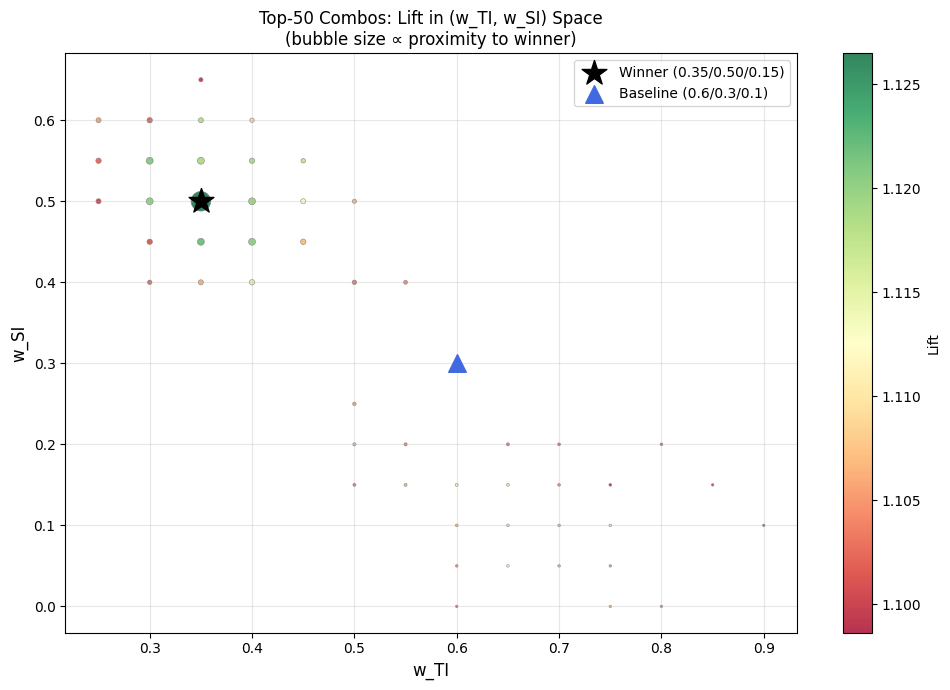

Saved: top50_sensitivity.png


In [12]:
# ── Plot D: Sensitivity bubble — top-50 combos in (w_TI, w_SI) space ─────────
results['dist_from_winner'] = np.sqrt(
    (results.w_TI - winner.w_TI)**2 +
    (results.w_SI - winner.w_SI)**2 +
    (results.w_LI - winner.w_LI)**2
)
top50 = results.head(50).copy()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    top50.w_TI, top50.w_SI,
    c=top50.lift, cmap='RdYlGn',
    s=(1 / (top50.dist_from_winner + 0.01)) * 2,
    alpha=0.8, edgecolors='grey', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.scatter([winner.w_TI], [winner.w_SI], marker='*', color='black', s=350, zorder=6,
           label=f'Winner ({winner.w_TI:.2f}/{winner.w_SI:.2f}/{winner.w_LI:.2f})')
if baseline_lift is not None:
    ax.scatter([0.6], [0.3], marker='^', color='royalblue', s=160, zorder=6,
               label='Baseline (0.6/0.3/0.1)')
ax.set_xlabel('w_TI', fontsize=12); ax.set_ylabel('w_SI', fontsize=12)
ax.set_title('Top-50 Combos: Lift in (w_TI, w_SI) Space\n'
             '(bubble size ∝ proximity to winner)', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'e:\agntworks_playground\top50_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top50_sensitivity.png')

## Step 9 — Winning Combo: Top-Decile Corridor × TOD Windows

In [13]:
w_vec = np.array([winner.w_TI, winner.w_SI, winner.w_LI])
agg['winner_score'] = (
    w_vec[0] * agg['TI_norm_mean'] +
    w_vec[1] * agg['SI_norm_mean'] +
    w_vec[2] * agg['LI_norm_mean']
)

score_thresh = agg['winner_score'].quantile(1 - TOP_DECILE)
top_windows  = agg[agg['winner_score'] >= score_thresh].sort_values(
    'winner_score', ascending=False).reset_index(drop=True)

print(f'Top-decile windows: {len(top_windows)} '
      f'(score ≥ {score_thresh:.4f})')
print(f'Mean RPH in top decile : ${top_windows.mean_rph.mean():,.0f}')
print(f'Mean RPH overall       : ${global_mean_rph:,.0f}')

disp = top_windows[[
    'corridor', 'TOD', 'flight_count',
    'mean_rph', 'TI_raw_mean', 'SI_raw_mean', 'LI_raw_mean',
    'winner_score'
]].head(25).copy()
disp.columns = ['Corridor', 'TOD', 'Flights', 'Mean RPH',
                'Avg TI', 'Avg SI', 'Avg LI', 'Score']
disp['Mean RPH'] = disp['Mean RPH'].apply(lambda x: f'${x:,.0f}')
disp[['Avg TI','Avg SI','Avg LI','Score']] = (
    disp[['Avg TI','Avg SI','Avg LI','Score']].round(2)
)
display(disp)

Top-decile windows: 180 (score ≥ 0.4558)
Mean RPH in top decile : $10,755
Mean RPH overall       : $9,547


,Corridor,TOD,Flights,Mean RPH,Avg TI,Avg SI,Avg LI,Score
0,San Antonio->Pittsburgh,13:00-15:59,8,"$7,692",6.00,4.75,4.50,0.74
1,Dallas->Boston,10:00-12:59,34,"$12,386",4.65,4.79,5.03,0.70
2,Boston->Phoenix Valley,10:00-12:59,40,"$6,674",5.50,3.90,5.30,0.65
3,Philadelphia->Houston,13:00-15:59,19,"$16,091",5.87,3.89,3.13,0.63
4,St. Louis->Boston,13:00-15:59,5,"$8,600",4.30,4.60,2.10,0.63
5,Seattle->Boston,10:00-12:59,22,"$11,634",6.91,3.23,3.77,0.61
6,San Antonio->Boston,10:00-12:59,20,"$8,969",5.75,3.50,4.25,0.60
7,Pittsburgh->Boston,13:00-15:59,40,"$7,970",4.32,4.30,2.22,0.60
8,DMV->Seattle,13:00-15:59,9,"$7,408",4.17,3.89,4.83,0.59
9,Seattle->South Florida,10:00-12:59,32,"$8,284",5.62,3.34,4.84,0.59


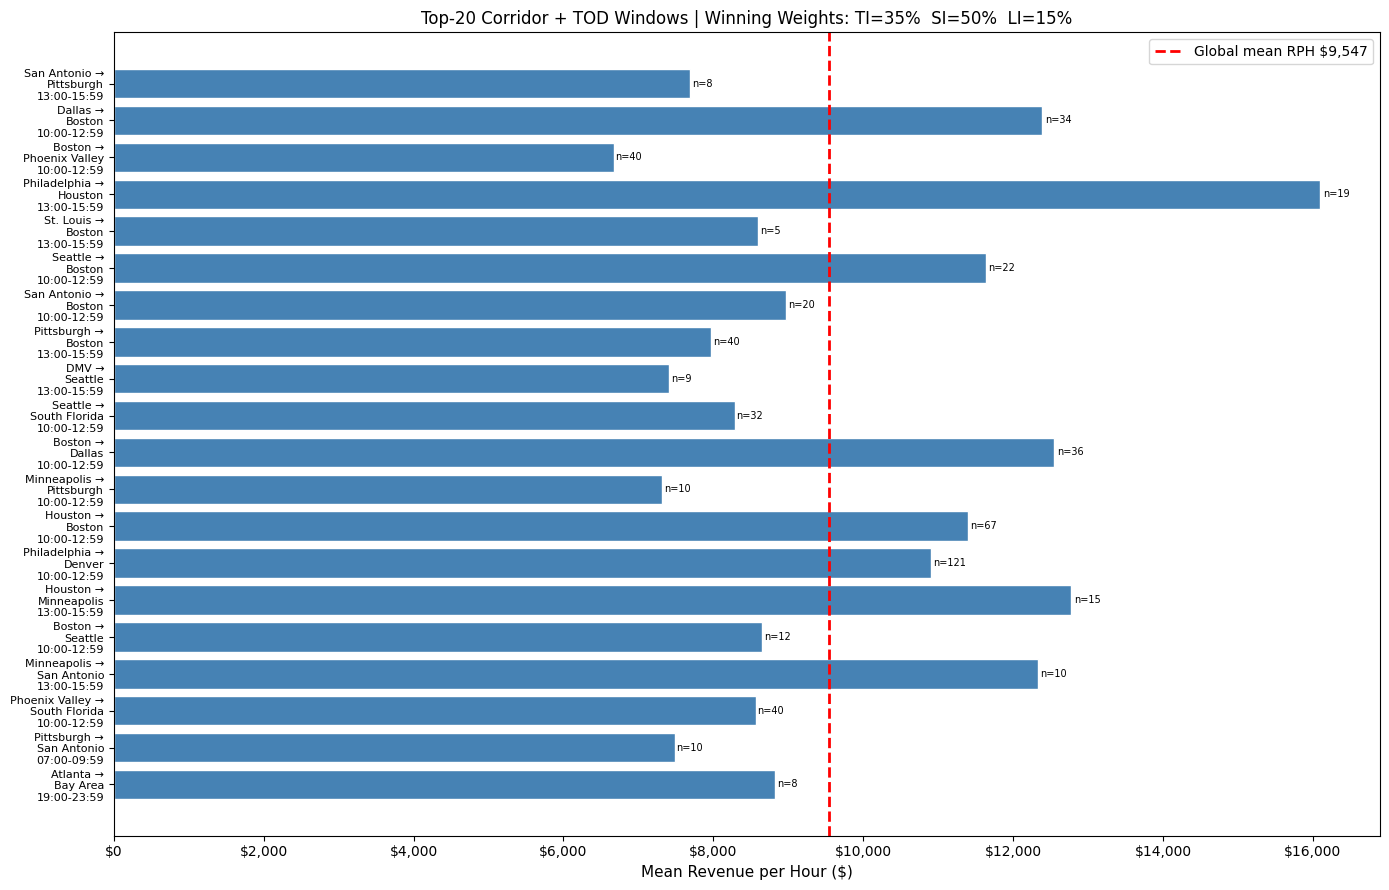

Saved: top20_corridors_winner.png


In [14]:
# ── Top-20 corridor bar chart ─────────────────────────────────────────────────
top20 = top_windows.head(20).copy()
top20['label'] = (top20['corridor'].str.replace('->', ' →\n', regex=False)
                  + '\n' + top20['TOD'])

fig, ax = plt.subplots(figsize=(14, 9))
ax.barh(range(len(top20)), top20['mean_rph'], color='steelblue', edgecolor='white')
ax.axvline(global_mean_rph, color='red', ls='--', lw=2,
           label=f'Global mean RPH ${global_mean_rph:,.0f}')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean Revenue per Hour ($)', fontsize=11)
ax.set_title(
    f'Top-20 Corridor + TOD Windows | '
    f'Winning Weights: TI={winner.w_TI:.0%}  SI={winner.w_SI:.0%}  LI={winner.w_LI:.0%}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, row in top20.iterrows():
    idx = list(top20.index).index(i)
    ax.text(row['mean_rph'] * 1.003, idx,
            f"n={int(row['flight_count'])}", va='center', fontsize=7)

plt.tight_layout()
plt.savefig(r'e:\agntworks_playground\top20_corridors_winner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top20_corridors_winner.png')

In [15]:
# ── Baseline vs Winner overlap analysis ───────────────────────────────────────
if baseline_lift is not None:
    b_vec = np.array([0.6, 0.3, 0.1])
    agg['baseline_score'] = (
        b_vec[0] * agg['TI_norm_mean'] +
        b_vec[1] * agg['SI_norm_mean'] +
        b_vec[2] * agg['LI_norm_mean']
    )
    b_thresh = agg['baseline_score'].quantile(1 - TOP_DECILE)
    agg['in_baseline'] = agg['baseline_score'] >= b_thresh
    agg['in_winner']   = agg['winner_score']   >= score_thresh

    both      = (agg['in_baseline'] &  agg['in_winner']).sum()
    only_base = (agg['in_baseline'] & ~agg['in_winner']).sum()
    only_win  = (~agg['in_baseline'] & agg['in_winner']).sum()

    print('Top-decile overlap: Baseline vs Winner')
    print(f'  In both        : {both}')
    print(f'  Baseline only  : {only_base}  (dropped by winner weighting)')
    print(f'  Winner only    : {only_win}   (gained by winner weighting)')
    print()

    rph_both  = agg.loc[agg['in_baseline'] &  agg['in_winner'], 'mean_rph'].mean()
    rph_base  = agg.loc[agg['in_baseline'] & ~agg['in_winner'], 'mean_rph'].mean()
    rph_win   = agg.loc[~agg['in_baseline'] & agg['in_winner'],  'mean_rph'].mean()
    print(f'  Mean RPH — shared windows    : ${rph_both:,.0f}')
    print(f'  Mean RPH — baseline-only (dropped) : ${rph_base:,.0f}')
    print(f'  Mean RPH — winner-only  (gained)   : ${rph_win:,.0f}')

Top-decile overlap: Baseline vs Winner
  In both        : 114
  Baseline only  : 66  (dropped by winner weighting)
  Winner only    : 66   (gained by winner weighting)

  Mean RPH — shared windows    : $10,767
  Mean RPH — baseline-only (dropped) : $9,976
  Mean RPH — winner-only  (gained)   : $10,733


## Final Summary

In [16]:
print('=' * 65)
print(' CONSTRAINED GRID OPTIMISATION SUMMARY')
print('=' * 65)
print(f' Data          : {len(df_clean):,} flights  |  {len(agg):,} corridor+TOD windows')
print(f' Grid          : {len(W)} weight combos (5 % steps, sum = 1.0)')
print(f' Lift metric   : mean_rph(top-{int(TOP_DECILE*100)} % windows) / '
      f'mean_rph(all windows)')
print()
if baseline_lift is not None:
    print(f' BASELINE   (0.60 / 0.30 / 0.10)  :  lift = {baseline_lift:.4f}  '
          f'top-decile RPH = ${results.loc[baseline_mask,"top_decile_mrph"].values[0]:,.0f}')
print(f' WINNER     ({winner.w_TI:.2f} / {winner.w_SI:.2f} / {winner.w_LI:.2f})         :  '
      f'lift = {winner.lift:.4f}  '
      f'top-decile RPH = ${winner.top_decile_mrph:,.0f}')
if baseline_lift is not None:
    print()
    print(f' Lift improvement over baseline : +{(winner.lift - baseline_lift)/baseline_lift*100:.2f} %')
print('=' * 65)
print()
print(' Output files:')
for fname in [
    'weight_optimization_ternary.png',
    'lift_heatmap_wTI_wSI.png',
    'lift_scatter_analysis.png',
    'top50_sensitivity.png',
    'top20_corridors_winner.png',
]:
    print(f'{fname}')

 CONSTRAINED GRID OPTIMISATION SUMMARY
 Data          : 89,183 flights  |  1,800 corridor+TOD windows
 Grid          : 231 weight combos (5 % steps, sum = 1.0)
 Lift metric   : mean_rph(top-10 % windows) / mean_rph(all windows)

 BASELINE   (0.60 / 0.30 / 0.10)  :  lift = 1.0974  top-decile RPH = $10,477
 WINNER     (0.35 / 0.50 / 0.15)         :  lift = 1.1265  top-decile RPH = $10,755

 Lift improvement over baseline : +2.65 %

 Output files:
weight_optimization_ternary.png
lift_heatmap_wTI_wSI.png
lift_scatter_analysis.png
top50_sensitivity.png
top20_corridors_winner.png
